# W8-1. Feature Selection & SVM

**오늘 할 일**
1. 저번 주 Logistic Regression 흐름을 다시 한 번 따라가 보기
2. `SelectKBest`로 descriptor(=feature) **몇 개**를 쓸지 정하기
3. 같은 개수로 **MLP**, **SVM**도 학습시켜서 성능 비교

> 📝 **descriptor = feature** — 분자 구조를 숫자로 바꾼 값. 동일한 의미.

**데이터**: `skin_irritation_2Ddesc.csv` (저번 시간에 만든 파일)

**구성**
- Part A — 저번 주 코드 복습 (셀 그대로 실행)
- Part B — 이번 주 실습 (✏️ 표시 셀은 직접 채워 넣기)


feature 너무 많이 하면 overfitting. 적으면 못맞춤.
mlp: multi layer perceptron. 뉴럴넷

In [23]:
import warnings
warnings.filterwarnings('ignore')

---
# Part A. 저번 주 복습

셀을 하나씩 `Shift+Enter`로 실행하면서 주석 읽어 봐.


## A-1. 데이터 불러오기

`pandas.read_csv`로 파일 읽고 `df`에 담기.
- `df.shape` → (행, 열)
- `df.head()` → 위 5줄 미리보기

✅ **예상**: `(39, 220)` — 화합물 39개, 열 220개.


In [7]:
import pandas as pd

df = pd.read_csv('skin_irritation_2Ddesc.csv')
print('shape:', df.shape)
df.head()


shape: (39, 220)


,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
2,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
3,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
4,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0


## A-2. X / y 나누고 descriptor 정리

- `y` = `label` 열 (피부 자극: 0/1)
- `X` = 나머지 숫자 descriptor

버릴 거 두 가지:
1. **NaN 있는 열** — 일부 descriptor는 특정 분자에서 계산이 실패해 `NaN`이 돼. 👉 저번 주 마지막에 `clf.fit(X, y)`가 터진 이유가 바로 이거야.
2. **표준편차 0.01 미만 열** — 거의 다 같은 값이면 구분력이 없으니 빼.

✅ **예상**: NaN 제거 `(39, 209)` → std 필터 `(39, 144)`


In [13]:
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

X = X.dropna(axis=1)                 # NaN 열 제거
print('NaN 제거:', X.shape)

X = X.loc[:, X.std() >= 0.01]        # 저분산 제거
print('std 필터:', X.shape)


NaN 제거: (39, 209)
std 필터: (39, 144)


## A-3. 전체 descriptor로 Logistic Regression

일단 다 넣고 돌려 봐.
- `clf.fit(X, y)` : 학습
- `clf.score(X, y)` : 학습 데이터 정확도 — 1.0에 가까워도 좋아하면 안 돼(**overfitting** 의심).
- `cross_val_score(..., cv=5)` : 5등분해서 돌아가며 검증. 진짜 성능은 이쪽.
- 함수 설명: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
- cross validation 설명: https://scikit-learn.org/stable/modules/cross_validation.html

cross validation. 아끼는 법: 5개로 토막내서 하나는 테스트 나머지는 트레이닝으로 모델 만들고 반복해서 평균내기. 어느 정도 검증되었다.
score를 y축,  # of feature등을 x축으로 train과 cv 그래프 그리기.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

'''
descriptor 단위가 달라서 표준화 (사실 2D descriptor 사용할 때는 normalization이 필수!)
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

standardscaler는 descriptor 값을 평균과 표준편차로 표준화시키는 방법. (나는 고등학교 때 수학 시간에 확률과 통계 시간에 배웠던 것 같은데...) normalization

또 다른 표준화 방식은 descriptor의 최대, 최소 값을 이용하는 것.
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

표준화 하는 이유
1) descriptor 범위가 너무 달라서 해석이 어려움 (MW: 100~700, logP: -2~8) -> y(0~1)=a*x1(MW)+b*x2(logp)+c  #모듈이 단순하면 해석(coeffitient a,b) 용이. 보고서 쓸 때 해석 넣으면 좋지만 해석이 쉬운건 결과가 안좋은 경우가 많아서 어렵다.
2) ML 모델 학습이 어려움 (descriptor 값의 스케일이 너무 다르면, loss 함수가 복잡해져서 학습이 느려짐)  #iteration 조금만 해도 잘 찾아감.
#fingerprint는 0,1 밖에 없으니 안함. 하면 0으로 수렴
'''

X_scaled = StandardScaler().fit_transform(X)   # descriptor값 표준화

clf = LogisticRegression(max_iter=5000)
clf.fit(X_scaled, y)
print('train :', clf.score(X_scaled, y))
print('CV5   :', cross_val_score(clf, X_scaled, y, cv=5).mean().round(3))



train : 0.9743589743589743
CV5   : 0.789


---
# Part B. 이번 주 실습

✏️ 셀 3개를 직접 채워. 바로 위 Part A를 참고하면 충분해.

1. `SelectKBest` + Logistic Regression으로 **최적 K** 찾기
2. 같은 K로 **MLP** — 로지스틱보다 나은가?
3. 같은 K로 **SVM** — `C`, `kernel` 바꿔 보기


## B-0. SelectKBest 개념

> 📌 **성능 숫자 해석 팁**: 샘플이 39개뿐이니까 5-fold CV는 fold당 8개 정도만 들어가. **±0.1 변동은 정상**이야. 미세한 차이로 모델 좋고 나쁨을 단정하지 마.

데이터는 39개, descriptor는 144개. 입력이 너무 많으면 노이즈에 묻혀서 패턴을 못 잡아. `SelectKBest`는 **y와 관련 높은 상위 K개**만 골라.

- 📖 <https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html>

> ⚠️ `SelectKBest(f_classif, ...)`는 스케일 영향을 안 받아서 원본 `X`에 써도 돼. 대신 **모델 학습 직전엔 반드시 `StandardScaler`**. 순서: `SelectKBest` → `StandardScaler` → 모델.

**사용법** (3줄):
```python
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=10)
X_new = selector.fit_transform(X, y)
```

K=10으로 뽑히는 descriptor 이름 먼저 확인.


In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
print(list(X.columns[selector.get_support()]))


['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


## ✏️ 실습 1 — Logistic Regression 최적 K

K를 바꿔 가며 5-fold CV 정확도 비교. 제일 높은 K가 **`best_k`**.

**힌트**
1. `for k in k_candidates:` 루프
2. 루프 안에서 `SelectKBest(f_classif, k)` → `StandardScaler` → `LogisticRegression(max_iter=5000)` 의 CV 점수
3. 가장 높은 k를 `best_k`에 저장 (다음 실습에서 재사용)

✅ **경향**: 너무 적으면 정보 부족, 너무 많으면 노이즈.


In [25]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

k_candidates = [5, 10, 15, 20, 25, 30, 40, 50]
best_k, best_score = None, -1

# TODO: 각 k에 대해 SelectKBest → StandardScaler → LogReg CV5
#       k, acc 출력 + best_k/best_score 업데이트
#       예시 출력: 'k=10: 0.793'
for k in k_candidates:
    # 1. 특성 선택: 전체 데이터(X, y)에서 상위 k개의 특성만 뽑아 X_selected 생성
    selector = SelectKBest(score_func=f_classif, k=k)
    X_selected = selector.fit_transform(X, y)
    
    # 2. 데이터 스케일링: 선택된 특성들만 모인 X_selected를 표준화하여 X_scaled 생성
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)
    
    # 3. 로지스틱 회귀 모델 훈련 및 5-Fold 교차 검증 (X_scaled 사용)
    clf = LogisticRegression(max_iter=5000, random_state=42)
    acc = cross_val_score(clf, X_scaled, y, cv=5).mean()
    
    print(f"k={k}: {acc:.3f}")
    
    # 최고 점수 갱신
    if acc > best_score:
        best_score = acc
        best_k = k

print("-" * 30)
print(f"🏆 최적의 K (best_k): {best_k} / 최고 정확도: {best_score:.3f}")

k=5: 0.668
k=10: 0.793
k=15: 0.793
k=20: 0.793
k=25: 0.743
k=30: 0.743
k=40: 0.664
k=50: 0.661
------------------------------
🏆 최적의 K (best_k): 10 / 최고 정확도: 0.793


## ✏️ 실습 2 — 같은 K로 MLP

실습 1의 `best_k` 그대로. 모델만 `LogisticRegression` → `MLPClassifier`.

**힌트**
- `from sklearn.neural_network import MLPClassifier`
- `MLPClassifier(random_state=0, max_iter=2000)`
- hidden layer 1개, hidden node 개수는 k와 동일하게 설정
- 데이터가 적으면 MLP가 로지스틱보다 **떨어질 수도** 있어. 그것도 배움이야.


In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# TODO: best_k로 SelectKBest → StandardScaler → MLPClassifier(random_state=0, max_iter=2000)
#       CV5 점수 출력 + 실습 1 결과와 한 줄 비교

# 1. 특성 선택: 실습 1에서 찾은 best_k(10)를 그대로 적용하여 추출
selector = SelectKBest(score_func=f_classif, k=best_k)
X_selected = selector.fit_transform(X, y)

# 2. 데이터 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# 3. MLP 모델 생성 및 5-Fold 교차 검증
# 교수님 힌트 반영: 은닉층 1개 및 노드 수는 k와 동일하게 설정 -> hidden_layer_sizes=(best_k,)
mlp = MLPClassifier(hidden_layer_sizes=(best_k,), max_iter=2000, random_state=0)
mlp_acc = cross_val_score(mlp, X_scaled, y, cv=5).mean()

print(f"📈 기존 로지스틱 회귀 최고 정확도: {best_score:.3f}")
print(f"🧠 다층 퍼셉트론(MLP) CV5 정확도: {mlp_acc:.3f}")

📈 기존 로지스틱 회귀 최고 정확도: 0.793
🧠 다층 퍼셉트론(MLP) CV5 정확도: 0.711


## B-3. SVM 개념

SVM은 **두 그룹 사이에 제일 넉넉한 경계선**을 찾아. 경계에 가까운 점(support vector)과의 거리(margin)를 최대로.

핵심 2개만 기억하면 돼.

| 이름 | 역할 | 크면 | 작으면 |
|------|------|------|--------|
| `C` | regularization의 역수 | 학습 데이터에 바짝 맞춤 → overfitting↑ | 경계 부드러움 → underfitting 가능 |
| `kernel` | 경계 모양 | `linear`: 직선 / `rbf`: 종 모양 곡선 / `poly`: 다항식 | — |

- 📖 SVC: <https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html>
- 📖 SVM 해설: <https://scikit-learn.org/stable/modules/svm.html>


## ✏️ 실습 3 — 같은 K로 SVM (`C` × `kernel`)

`best_k`로 descriptor 뽑고, `C`와 `kernel` 조합을 표처럼 찍어 봐.

**힌트**
- `from sklearn.svm import SVC`
- 이중 for: `for C in [0.1, 1, 10]: for kernel in ['linear', 'rbf', 'poly']:`
- RBF/poly는 스케일에 민감 → **`StandardScaler` 필수**
- 💡 `poly`는 경고 뜰 수 있는데 정상. 거슬리면 `import warnings; warnings.filterwarnings('ignore')`.


In [30]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# TODO: best_k로 X_sel 만들고, C × kernel 조합 CV5 출력
#       예시 출력: 'C=0.1, kernel=linear : 0.775'

# 1. 실습 1에서 찾은 최적의 특성 개수 (best_k = 10) 고정

# 2. X_sel (10개 특성 추출) 및 스케일링
# RBF와 poly 커널은 데이터 스케일에 매우 민감하므로 반드시 StandardScaler를 거쳐야 함.
selector = SelectKBest(score_func=f_classif, k=best_k)
X_sel = selector.fit_transform(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

print(f"🚀 SVM 5-Fold 교차 검증 탐색 시작 (K={best_k})")
print("-" * 40)

best_svm_score = -1
best_svm_params = ""

# 3. C와 kernel 조합을 위한 이중 for문 구성
for C in [0.1, 1, 10]:
    for kernel in ['linear', 'rbf', 'poly']:
        
        # SVM 모델 정의 (해당 C와 kernel 값 적용)
        svm = SVC(C=C, kernel=kernel, random_state=42)
        
        # 5-Fold 교차 검증 수행
        acc = cross_val_score(svm, X_scaled, y, cv=5).mean()
        
        # 예시 포맷으로 결과 출력
        print(f"C={C}, kernel={kernel} : {acc:.3f}")
        
        # 최고 점수 업데이트
        if acc > best_svm_score:
            best_svm_score = acc
            best_svm_params = f"C={C}, kernel={kernel}"

print("-" * 40)
print(f"🏆 최적의 SVM 하이퍼파라미터: {best_svm_params} / 최고 정확도: {best_svm_score:.3f}")

🚀 SVM 5-Fold 교차 검증 탐색 시작 (K=10)
----------------------------------------
C=0.1, kernel=linear : 0.775
C=0.1, kernel=rbf : 0.668
C=0.1, kernel=poly : 0.668
C=1, kernel=linear : 0.689
C=1, kernel=rbf : 0.746
C=1, kernel=poly : 0.693
C=10, kernel=linear : 0.711
C=10, kernel=rbf : 0.768
C=10, kernel=poly : 0.614
----------------------------------------
🏆 최적의 SVM 하이퍼파라미터: C=0.1, kernel=linear / 최고 정확도: 0.775


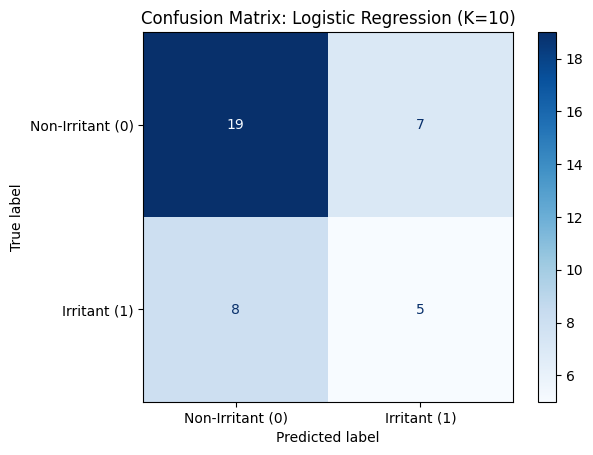

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. 1위 모델 파이프라인 세팅 (최적 K=10 적용)
# 교차 검증 시 데이터 누수를 막기 위해 파이프라인으로 묶어서 진행합니다.
best_pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=10)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=5000, random_state=42))
])

# 2. 교차 검증을 통해 전체 데이터(39개)에 대한 예측값 생성
y_pred_cv = cross_val_predict(best_pipeline, X, y, cv=5)

# 3. 혼동 행렬 생성
cm = confusion_matrix(y, y_pred_cv)

# 4. 시각화 (파란색 색상 테마 적용)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Irritant (0)', 'Irritant (1)'])
disp.plot(cmap='Blues')

# 그래프 제목 설정 및 출력
plt.title('Confusion Matrix: Logistic Regression (K=10)')
plt.show()

---
## 스스로 확인

세 실습을 다 채워 실행했으면, 아래 질문에 머릿속으로 답해 봐.

- (Q1) 최적 K는 몇? 왜?
- (Q2) 같은 K에서 MLP가 로지스틱보다 좋게 나올까? 이유는?
- (Q3) SVM에서 제일 좋은 `(C, kernel)` 조합은?


In [ ]:
바람직한 k 개수: 40 -> 20% cross validation으로 날아감 -> 40-8=32? -> 8개가 좋다. 하지만 더 쓴다고 뭐라할수는 없다.
소수점 둘째자리에서 차이나는 정도는 큰 차이 안난다고 본다.
k 5~10차이 적은데 그 안에서 성능폭이 바뀌는걸 또. 세부적인 폭 안에서의 변화.
로지스틱이 제일 잘 나온 이유: 데이터 적으면 단순한게 좋다.

In [ ]:
기말 고민:
이렇게 데이터 서치 한다음 표 하나로 보여줄 방법 고민. svm c 성능, linear k 성능 등으로 표로 보여주거나 learning curve로 보여주기 등. 어떻게 보여주는게 좋을까.
linear로 오버피팅 줄이고 피처 개수 줄여서 오버피팅 줄이고 해서 제한된 범위 내에서는 합리적이다. 등으로 내 의사결정이 합리적이다. 복잡한 알고리즘을 쓰면 데이터를 이렇게 늘려서 합리적이다. 이런 식으로.